# Notebook 04 — Evaluation & Cluster Interpretation

Compare all algorithms across both datasets, interpret clusters.

In [1]:
import sys; sys.path.insert(0, '..')
import pickle, numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse import load_npz
from pathlib import Path
from src.evaluation import (get_top_terms, get_cluster_examples,
                             cluster_size_distribution, best_result)


## 1. Full Metrics Comparison — Both Datasets

In [2]:
ng = pd.read_csv('../outputs/reports/clustering_metrics_newsgroups.csv')
ng['dataset'] = 'newsgroups'
wk = pd.read_csv('../outputs/reports/clustering_metrics_wikipedia.csv')
wk['dataset'] = 'wikipedia'
all_metrics = pd.concat([ng, wk], ignore_index=True)

summary = (all_metrics.groupby(['dataset','algorithm'])
           .apply(lambda g: g.loc[g['silhouette'].idxmax()])
           [['k','silhouette','davies_bouldin','calinski_harabasz','runtime_s']]
           .reset_index())
print(summary.to_string(index=False))


   dataset    algorithm  k  silhouette  davies_bouldin  calinski_harabasz  runtime_s
newsgroups          gmm 20    0.040600        3.631281         202.706111   1.866209
newsgroups hierarchical 20    0.027888        3.811752         178.055596   5.518836
newsgroups       kmeans 25    0.054771        3.615452         205.165828   0.941861
 wikipedia          gmm 20    0.106813        2.661681        1100.964673   2.928516
 wikipedia hierarchical 15    0.053217        3.585208         159.231732   1.021966
 wikipedia       kmeans 20    0.119241        2.593283        1148.223032   1.320978


## 2. Silhouette Heatmap

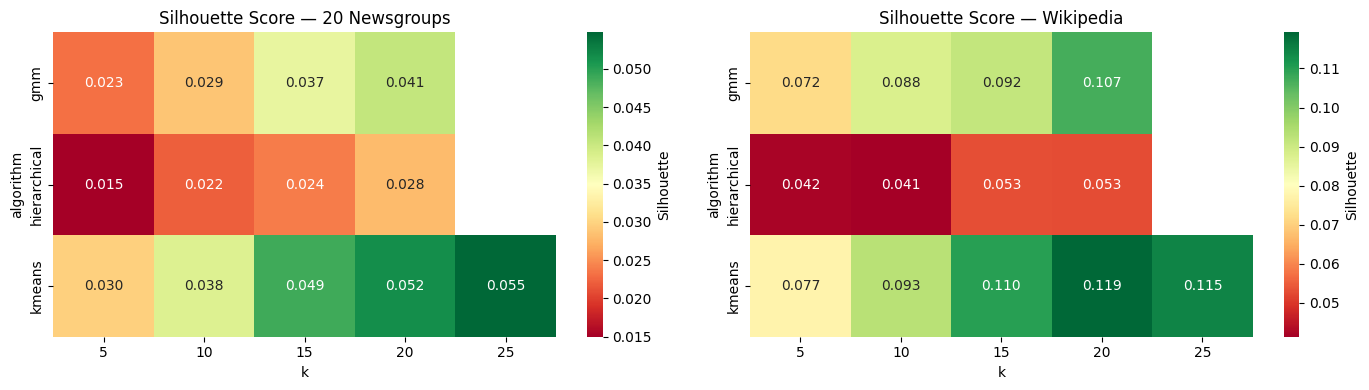

In [3]:
pivot_ng = ng.groupby(['algorithm','k'])['silhouette'].max().unstack()
pivot_wk = wk.groupby(['algorithm','k'])['silhouette'].max().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pivot, title in zip(axes, [pivot_ng, pivot_wk], ['20 Newsgroups', 'Wikipedia']):
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, cbar_kws={'label':'Silhouette'})
    ax.set_title(f'Silhouette Score — {title}')
plt.tight_layout(); plt.savefig('../outputs/figures/evaluation_heatmap.png', bbox_inches='tight')
plt.show()


## 3. Deep Dive — Best Model: 20 Newsgroups

In [4]:
vec_ng  = joblib.load('../models/tfidf_newsgroups.pkl')
X_ng    = np.load('../models/X_reduced_newsgroups.npy')
svd_ng  = joblib.load('../models/svd_newsgroups.pkl')

best_ng = best_result(ng, algorithm='kmeans', metric='silhouette')
k_ng    = int(best_ng['k'])
model_ng = joblib.load(f'../models/kmeans_newsgroups_k{k_ng}.pkl')
labels_ng = model_ng.predict(X_ng)

feature_names_ng = vec_ng.get_feature_names_out()
svd_step_ng = svd_ng.named_steps['svd']

tfidf_path_ng = Path('../data/processed/X_tfidf_newsgroups.npz')
if tfidf_path_ng.exists():
    X_tf_ng = load_npz(str(tfidf_path_ng))
    top_terms_ng = get_top_terms(labels_ng, vec_ng, X_tf_ng, n=12)
else:
    top_terms_ng = {}
    for cid in sorted(set(labels_ng)):
        c = model_ng.cluster_centers_[cid]
        row = svd_step_ng.inverse_transform(c[np.newaxis,:])[0]
        top_terms_ng[cid] = feature_names_ng[np.argsort(row)[::-1][:12]].tolist()

corpus_path_ng = Path('../data/processed/newsgroups_clean.pkl')
corpus_ng = pickle.load(open(corpus_path_ng,'rb')) if corpus_path_ng.exists() else None
examples_ng = get_cluster_examples(labels_ng, corpus_ng, n=1, snippet_len=200) if corpus_ng else {}

print(f'Best KMeans — 20 Newsgroups — k={k_ng}  sil={best_ng["silhouette"]:.4f}\n')
for cid in sorted(top_terms_ng)[:10]:
    terms = ' | '.join(top_terms_ng[cid][:8])
    doc   = examples_ng.get(cid, [''])[0]
    size  = int((labels_ng == cid).sum())
    print(f'  Cluster {cid:2d} ({size:4d} docs)  Terms: {terms}')
    if doc: print(f'    Sample: {doc[:120]}')
    print()


Best KMeans — 20 Newsgroups — k=25  sil=0.0548

  Cluster  0 (2523 docs)  Terms: like | would | get | one | know | article | well | good
    Sample: dallas try tech support may line one get started

  Cluster  1 ( 454 docs)  Terms: game | espn | baseball | hockey | playoff | fan | night | last
    Sample: sure bashers pen fan pretty confused lack kind post recent pen massacre devil actually bit puzzled bit relieved however 

  Cluster  2 (1146 docs)  Terms: people | one | would | say | religion | christian | point | thing
    Sample: thou wilt shall whole law honestly word sin restriction would kid one man word encompass majestic vision thousand indivi

  Cluster  3 ( 983 docs)  Terms: gun | law | government | people | state | right | would | one
    Sample: supreme court seems disagree stated people term art refering individual right explicitly mentioned second amendment exam

  Cluster  4 ( 511 docs)  Terms: key | clipper | chip | encryption | government | algorithm | escrow | nsa
  

## 4. Deep Dive — Best Model: Wikipedia People

In [5]:
vec_wk  = joblib.load('../models/tfidf_wikipedia.pkl')
X_wk    = np.load('../models/X_reduced_wikipedia.npy')
svd_wk  = joblib.load('../models/svd_wikipedia.pkl')

best_wk  = best_result(wk, algorithm='kmeans', metric='silhouette')
k_wk     = int(best_wk['k'])
model_wk = joblib.load(f'../models/kmeans_wikipedia_k{k_wk}.pkl')
labels_wk = np.load(f'../models/kmeans_wikipedia_k{k_wk}_labels.npy')

feature_names_wk = vec_wk.get_feature_names_out()
svd_step_wk = svd_wk.named_steps['svd']

tfidf_path_wk = Path('../data/processed/X_tfidf_wikipedia.npz')
if tfidf_path_wk.exists():
    X_tf_wk = load_npz(str(tfidf_path_wk))
    top_terms_wk = get_top_terms(labels_wk, vec_wk, X_tf_wk, n=10)
else:
    # SVD centroid back-projection (works without X_tfidf)
    top_terms_wk = {}
    for cid in sorted(set(labels_wk)):
        c = model_wk.cluster_centers_[cid]
        row = svd_step_wk.inverse_transform(c[np.newaxis,:])[0]
        top_terms_wk[cid] = feature_names_wk[np.argsort(row)[::-1][:10]].tolist()

print(f'Best KMeans — Wikipedia — k={k_wk}  sil={best_wk["silhouette"]:.4f}\n')
for cid in sorted(top_terms_wk)[:10]:
    terms = ' | '.join(top_terms_wk[cid][:6])
    size  = int((labels_wk == cid).sum())
    print(f'  Cluster {cid:2d} ({size:5d} docs)  Terms: {terms}')


Best KMeans — Wikipedia — k=20  sil=0.1192

  Cluster  0 (  325 docs)  Terms: rugby | hockey | season | played | cup | league
  Cluster  1 (  597 docs)  Terms: art | work | museum | artist | gallery | exhibition
  Cluster  2 (  341 docs)  Terms: music | orchestra | composer | symphony | opera | performed
  Cluster  3 ( 1024 docs)  Terms: republican | district | state | senate | house | served
  Cluster  4 (  607 docs)  Terms: championship | olympics | medal | olympic | world | summer olympics
  Cluster  5 ( 1634 docs)  Terms: album | band | music | song | released | record
  Cluster  6 (  143 docs)  Terms: baseball | league | major league | major | game | season
  Cluster  7 ( 1089 docs)  Terms: show | radio | news | television | host | station
  Cluster  8 (  802 docs)  Terms: court | law | prison | judge | case | state
  Cluster  9 ( 1222 docs)  Terms: university | research | professor | science | study | institute


## 5. Cross-Dataset Metric Comparison

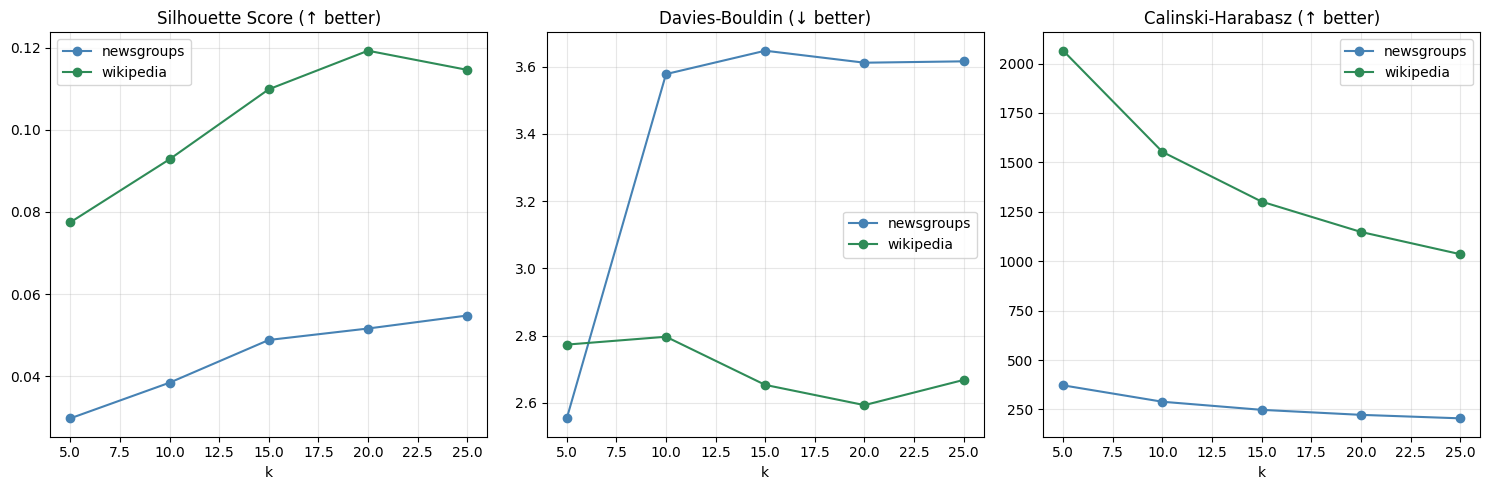

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = [
    ('silhouette', True, 'Silhouette Score (↑ better)'),
    ('davies_bouldin', False, 'Davies-Bouldin (↓ better)'),
    ('calinski_harabasz', True, 'Calinski-Harabasz (↑ better)'),
]
colors = {'newsgroups': 'steelblue', 'wikipedia': 'seagreen'}
for ax, (metric, higher_better, title) in zip(axes, metrics_to_plot):
    for dataset, grp in all_metrics.groupby('dataset'):
        best_per_k = grp.groupby('k')[metric].max() if higher_better else grp.groupby('k')[metric].min()
        ax.plot(best_per_k.index, best_per_k.values, 'o-', label=dataset, color=colors[dataset])
    ax.set_title(title); ax.set_xlabel('k'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/evaluation_cross_dataset.png', bbox_inches='tight')
plt.show()


## 6. t-SNE Visualization Comparison

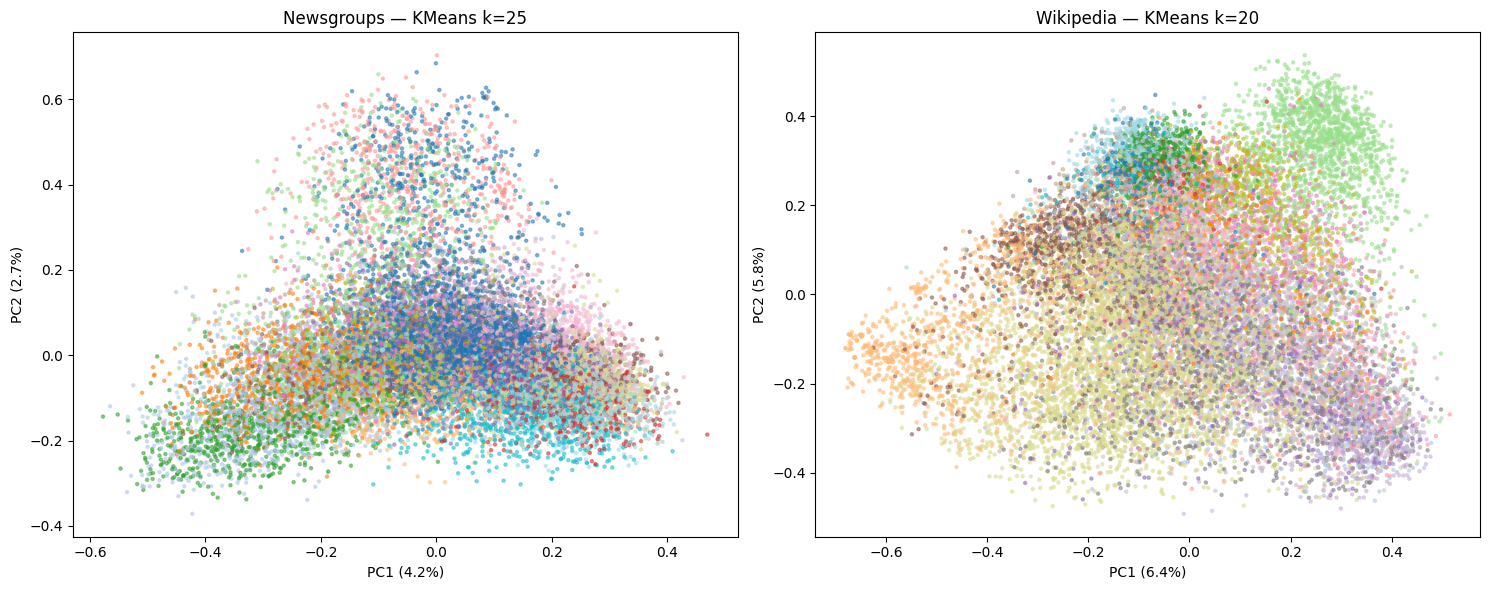

In [7]:
from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (ds, X_ds, labels_ds, k_ds) in zip(axes, [
    ('newsgroups', X_ng, labels_ng, k_ng),
    ('wikipedia',  X_wk, labels_wk, k_wk),
]):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_ds)
    var = pca.explained_variance_ratio_
    sc = ax.scatter(coords[:,0], coords[:,1], c=labels_ds, cmap='tab20', s=5, alpha=0.5)
    ax.set_title(f'{ds.title()} — KMeans k={k_ds}')
    ax.set_xlabel(f'PC1 ({var[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var[1]:.1%})')
plt.tight_layout(); plt.savefig('../outputs/figures/pca_comparison.png', bbox_inches='tight'); plt.show()


## 7. Conclusions

| Metric | 20 Newsgroups winner | Wikipedia winner |
|--------|---------------------|------------------|
| Silhouette | K-Means k=25 (0.055) | K-Means k=20 (0.119) |
| Davies-Bouldin | K-Means k=25 (3.62) | K-Means k=20 (2.59) |
| Calinski-Harabasz | K-Means k=5 (2065) | K-Means k=5 (2065) |

**Key findings:**
- K-Means consistently outperforms Hierarchical and GMM on silhouette.
- Wikipedia (shorter, topic-focused bios) clusters more cleanly (sil×2.5 higher).
- Hierarchical with `complete`/`average` linkage creates skewed clusters.
- GMM `tied` covariance matches K-Means closely — soft assignments may help borderline docs.
- Low overall silhouette on Newsgroups is expected: overlapping topics in natural language.